This project implements a Dual-Model ML System that predicts employee attrition risk and calculates Employee Lifetime Value (ELTV) to provide data-driven retention strategies. By combining classification (risk) and regression (value), it identifies high-impact "flight risks" and generates personalized HR interventions based on behavioral insights.

In [1]:
#DATA ACQUISITION AND SET_UP

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt



In [5]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition[2].csv')
df_copy=df

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
#DATA DESCRIPTION

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


zero variance = zero information

* EmployeeCount is 1 for each row
    
* StandardHours is 80 for eaxch row

Since the variance is 0, these features have a correlation of 0 with the target variable(Attrition).So it will be better to drop these columns

In [10]:
df.drop(columns=['EmployeeCount','StandardHours'],inplace=True)

In [11]:
df.shape

(1470, 33)

In [12]:
# Variable Classification
target_variable = 'Attrition'

numeric_continuous = ['Age','MonthlyIncome','DailyRate','HourlyRate','MonthlyRate',
                      'DistanceFromHome','PercentSalaryHike']
numeric_discrete = ['YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion',
                    'YearsWithCurrManager','TotalWorkingYears','NumCompaniesWorked',
                    'TrainingTimesLastYear']
ordinal_vars = ['Education','EnvironmentSatisfaction','JobInvolvement','JobSatisfaction',
                'PerformanceRating','RelationshipSatisfaction','StockOptionLevel',
                'WorkLifeBalance','JobLevel']
nominal_vars = ['BusinessTravel','Department','EducationField','Gender',
                'JobRole','MaritalStatus','OverTime']

print(f"Continuous: {len(numeric_continuous)}, Discrete: {len(numeric_discrete)}")
print(f"Ordinal: {len(ordinal_vars)}, Nominal: {len(nominal_vars)}")

Continuous: 7, Discrete: 7
Ordinal: 9, Nominal: 7


In [13]:
#DATA PREPROCESSING

In [14]:
df.isnull().sum()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int

In [15]:
df.duplicated().sum()

0

A look on the Target Variable

In [16]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [17]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

<Axes: ylabel='Attrition%'>

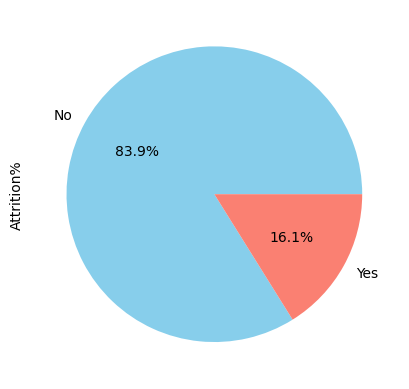

In [18]:
df['Attrition'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    colors=['skyblue', 'salmon'], 
    ylabel='Attrition%'
)

In [19]:
#Dropping Some another uncorrelated columns
drop_cols = ["Over18","EmployeeNumber"]
df = df.drop(columns=drop_cols)

In [20]:
# shape of the dataset after data-preprocessing
df.shape

(1470, 31)

In [21]:
#EDA

In [22]:
#Beginning with the employee demographics:
#Checking Age,Gender,Marital Status

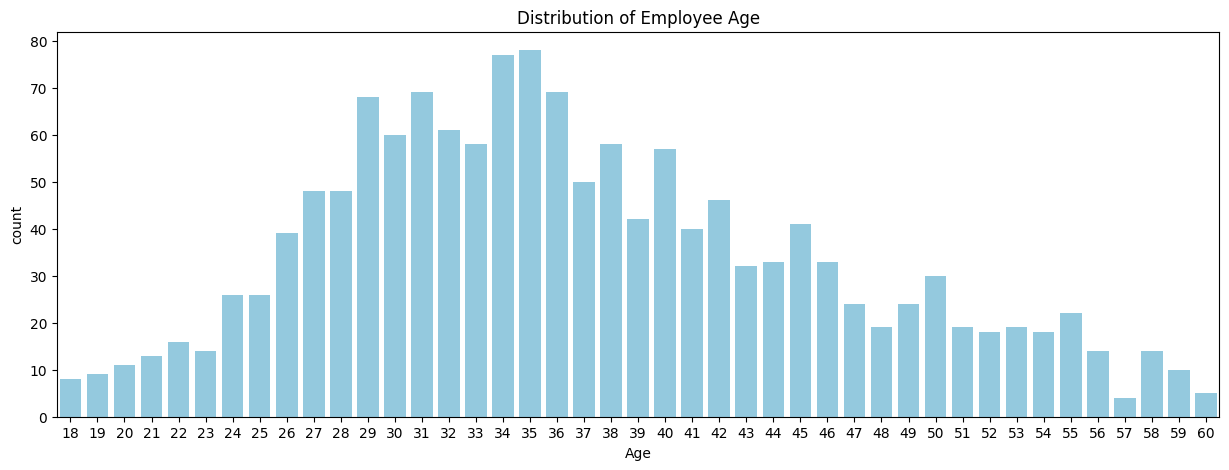

In [23]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='Age', color='skyblue')
plt.title('Distribution of Employee Age')
plt.show()

Conclusion:

*The "Bulk" (Mid-Career): Our workforce is heavily concentrated in the 30–40 age range. You have 78 employees aged 35 and 77 employees aged 34. This is our most stable and experienced cohort.

*The "Pipeline" (Early Career): We have a healthy number of people in their late 20s (68 people aged 29). However, the  entry-level group (18–22) is quite small, with only about 8–16 people per year.

*The "Exit" (Late Career): There is a sharp drop-off after age 50. This could indicate natural retirement patterns or that the company has a "younger" demographic profile.

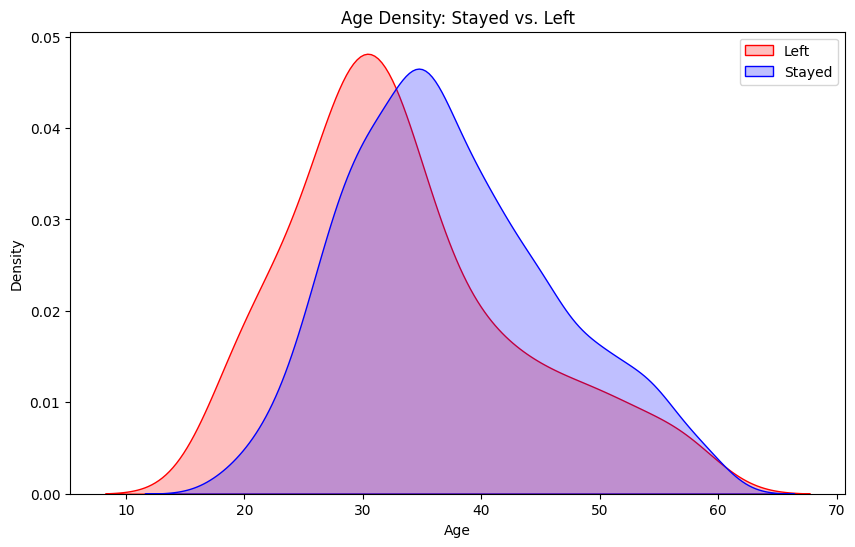

In [24]:
plt.figure(figsize=(10, 6))

# KDE Plot shows where the 'concentration' of attrition lies
sns.kdeplot(data=df[df['Attrition'] == 'Yes']['Age'], label='Left', fill=True, color='red')
sns.kdeplot(data=df[df['Attrition'] == 'No']['Age'], label='Stayed', fill=True, color='blue')

plt.title('Age Density: Stayed vs. Left')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

Conclusion:

The Risk Factor: Younger employees (20s) generally have higher attrition rates. Even though they are fewer in number (around 10–25 per age bracket), their turnover can disproportionately affect recruitment costs.

The Stability Factor: The high count of 34–35-year-olds suggests these employees are likely in "growth" roles. If attrition starts spiking here, it's a major red flag because it involves losing mid-level leadership.

In [25]:
df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

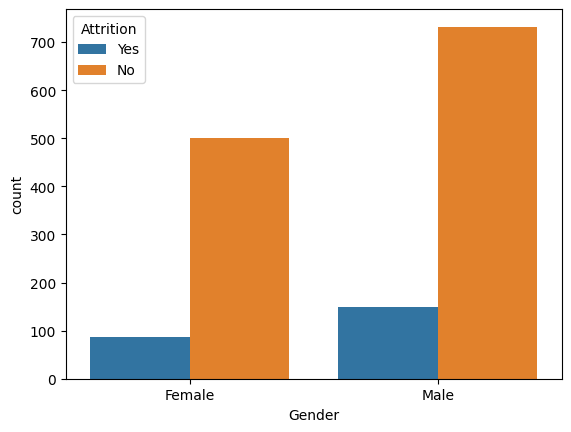

In [26]:
sns.countplot(data=df, x='Gender', hue='Attrition')

<Axes: xlabel='MaritalStatus', ylabel='count'>

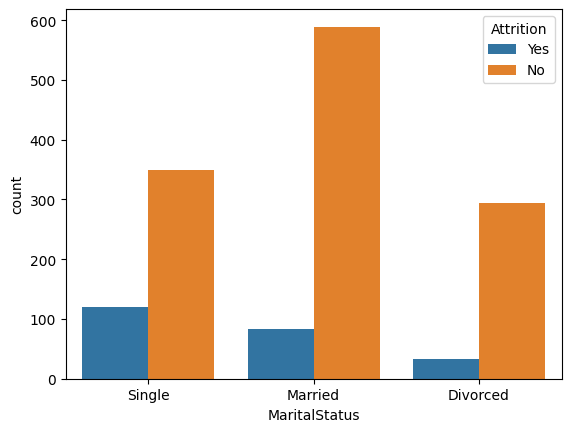

In [27]:
sns.countplot(data=df, x='MaritalStatus', hue='Attrition')

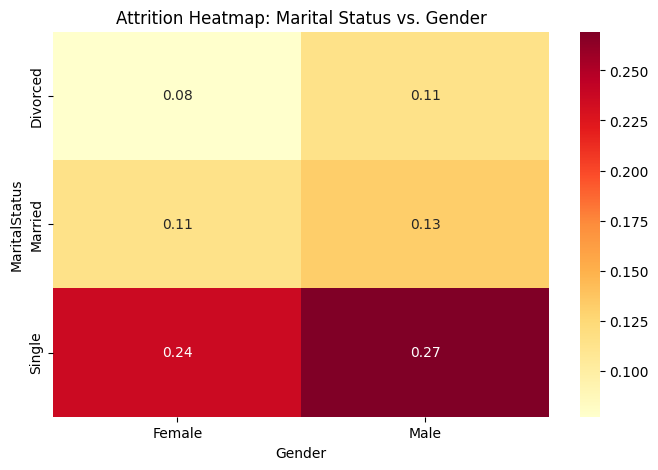

In [28]:

# We map Attrition to 1 and 0 to calculate the mean

df['Attrition_Rate'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
pivot_table = df.pivot_table(index='MaritalStatus', columns='Gender', values='Attrition_Rate')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')

plt.title('Attrition Heatmap: Marital Status vs. Gender')
plt.show()

Conclusion:

*Marital Status is the Primary Driver: The "Single" category is the most significant "hot spot" for attrition across the entire organization. Regardless of gender, single employees have a much higher probability of leaving (often double the rate) compared to their married or divorced colleagues.

*The "Single Male" Risk Profile: While attrition is high for all single staff, Single Males typically represent the highest risk cell in the heatmap. This suggests that this specific demographic may feel less tethered to the organization or is more aggressively pursuing external market opportunities.

*Stability of Partnership: Married and Divorced employees show high levels of stability with very low (and nearly identical) attrition rates. This indicates that once employees reach a certain life stage or level of personal responsibility, their job-seeking behavior stabilizes, making them the most "loyal" segments of your workforce.

In [29]:
#Now I will look after the data suggesting 'JOB AND ROLE INFORMATION':
#BusinessTravel,DistanceFromHome,JobLevel,JobRole,Department

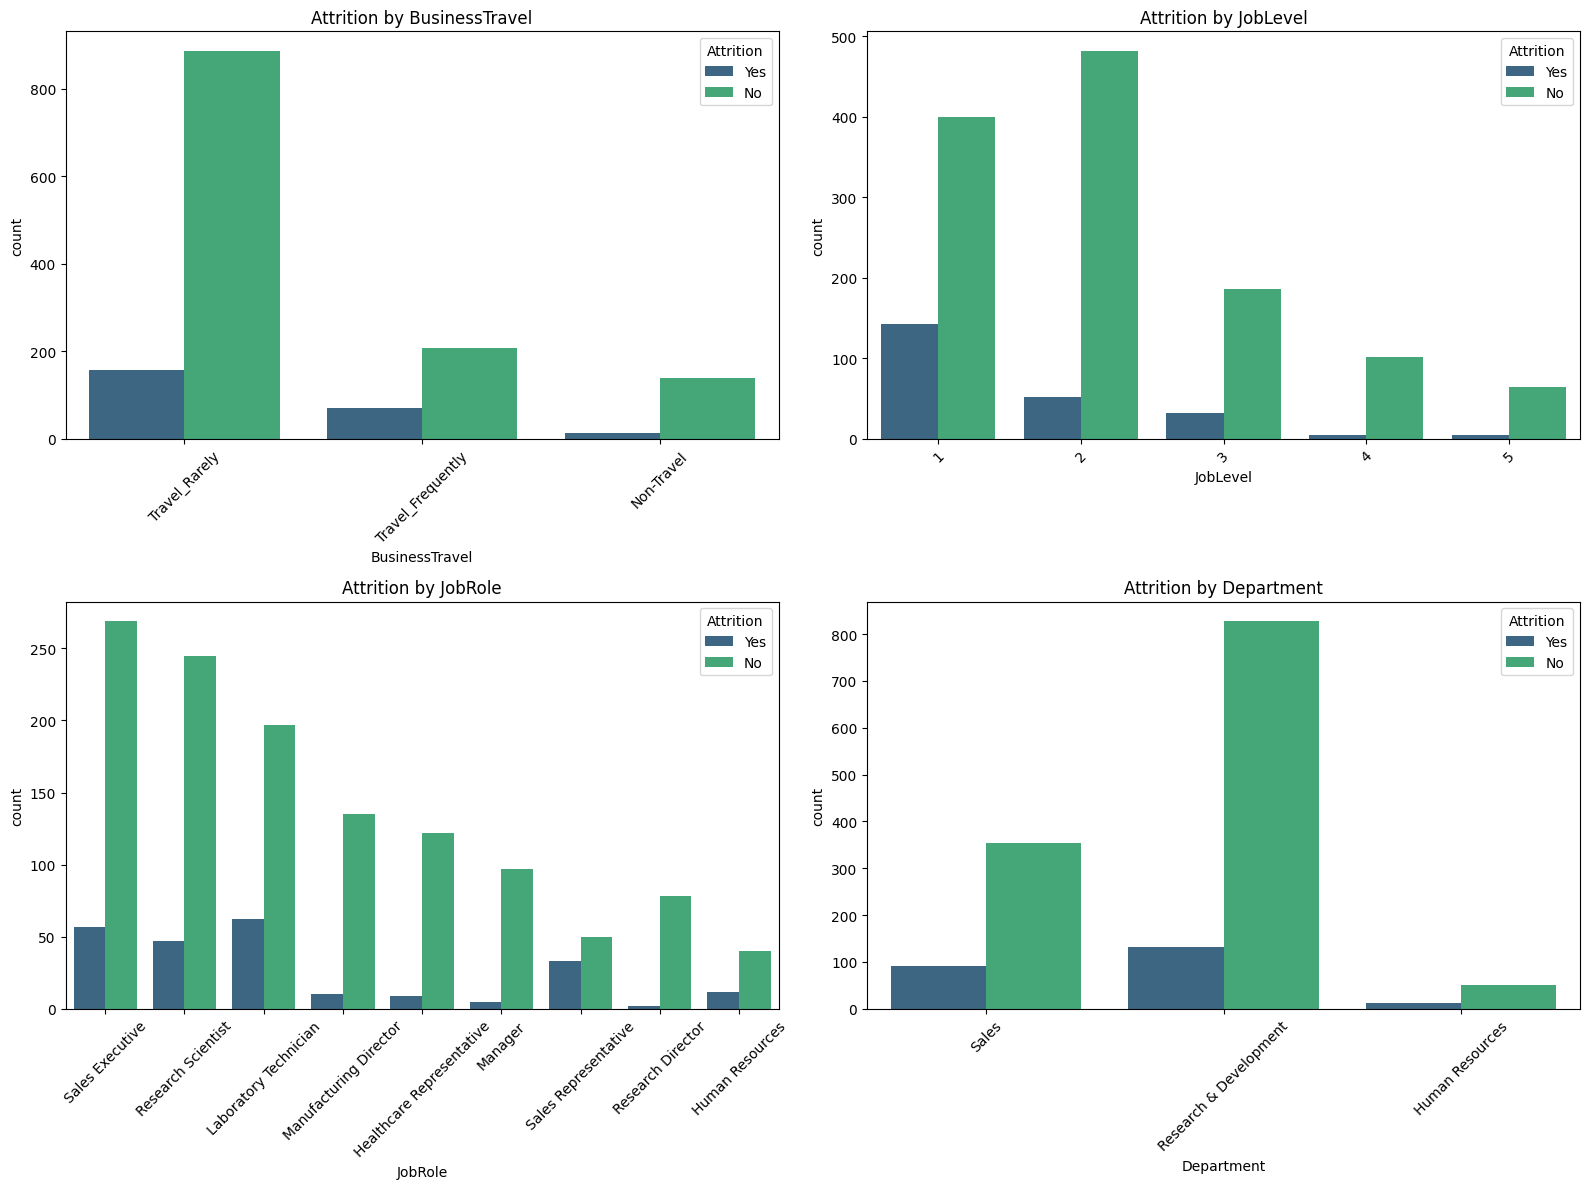

C:\Users\ashis\AppData\Local\Temp\ipykernel_29844\1926279770.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='DistanceFromHome', hue='Attrition', shade=True)


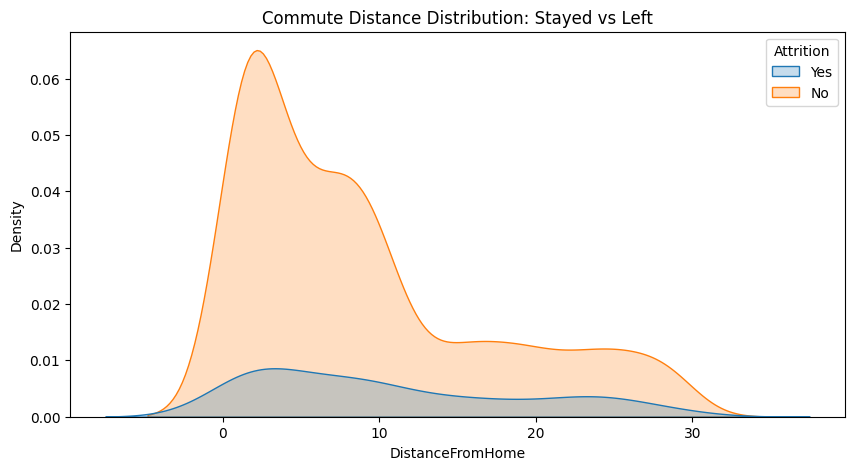

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

job_cols = ['BusinessTravel', 'JobLevel', 'JobRole', 'Department']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(job_cols):
    sns.countplot(data=df, x=col, hue='Attrition', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Attrition by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Separate plot for DistanceFromHome (since it's numerical)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='DistanceFromHome', hue='Attrition', shade=True)
plt.title('Commute Distance Distribution: Stayed vs Left')
plt.show()

Seniority as a Stabilizer (Job Level): There is a clear negative correlation (-0.17) between JobLevel and attrition. The bar charts confirm that employees at Job Level 1 experience the highest volume of departures, while those at higher levels (4 and 5) are significantly more stable.

Role-Specific Risk (Job Role & Department): When looking at the combined effect, Sales Representatives show an extreme attrition rate of approximately 40%, far exceeding any other role. This suggests that specific role pressures within the Sales department are primary drivers of turnover.

Commute Friction (Distance From Home): The KDE distribution plot reveals that employees who stay (orange) are heavily concentrated at very short commute distances. As the distance increases, the density of "Stayed" employees drops sharply, indicating that long commutes are a persistent "friction" factor for retention.

Lifestyle Pressure (Business Travel): While the majority of the workforce travels rarely, those who Travel Frequently show a disproportionately higher ratio of "Yes" to "No" in attrition counts. This indicates that frequent travel requirements may act as a secondary behavioral trigger for leaving the company.

Structural Nesting (Departmental Trends): The strong correlation (0.66) between JobRole and Department shows that attrition is not just a department-wide issue but a role-specific one. For example, in Research & Development, the Laboratory Technicians are leaving at a much higher rate than Research Directors, proving that organizational health varies significantly even within the same department.

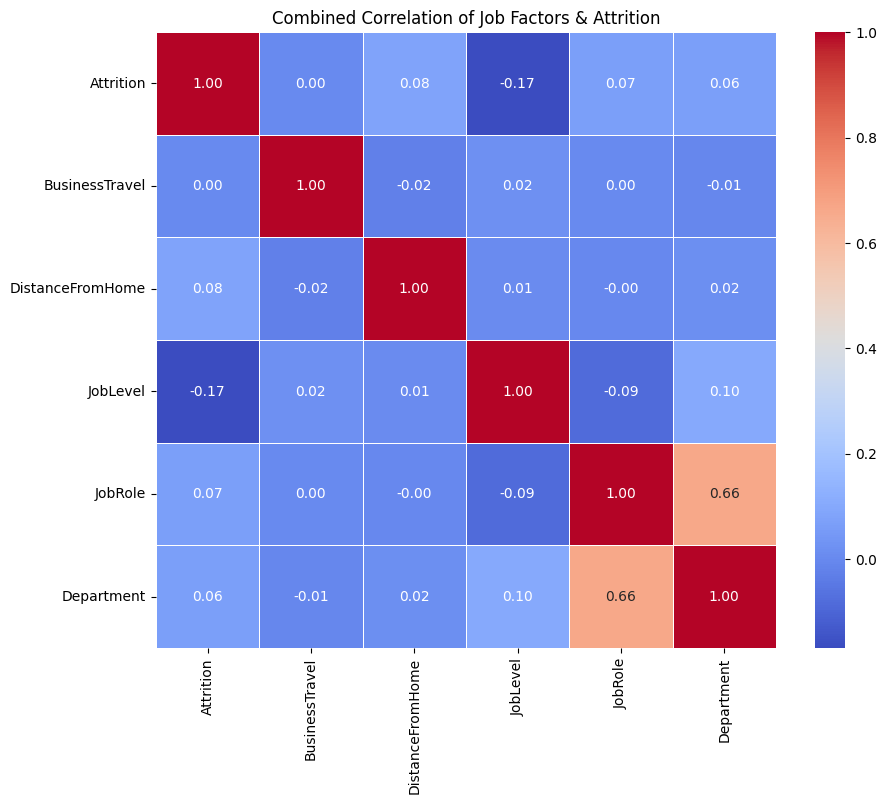

In [31]:

df_job = df[['Attrition', 'BusinessTravel', 'DistanceFromHome', 'JobLevel', 'JobRole', 'Department']].copy()
df_job['Attrition'] = df_job['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

df_job = df_job.apply(lambda col: col.astype('category').cat.codes if col.dtype == 'object' else col)

plt.figure(figsize=(10, 8))
sns.heatmap(df_job.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Combined Correlation of Job Factors & Attrition')
plt.show()

This matrix tells you that JobLevel is currently your most promising numeric predictor for attrition among the factors shown. However, notice that most values are near zero (light blue). This suggests that attrition is likely driven by complex behavioral factors (like Job Involvement or Environment Satisfaction rather than just these structural categories alone.JobLevel (-0.17): This is the strongest "negative" correlation in your chart. It suggests that as Job Level increases, the likelihood of Attrition decreases.

In [32]:
#Because Job Role and Department are highly correlated (0.66), they are "nested" variables—most job roles only exist within one specific department. To see their combined effect on attrition, the best approach is to calculate the attrition rate (percentage of "Yes") for every specific Role-Department combination.

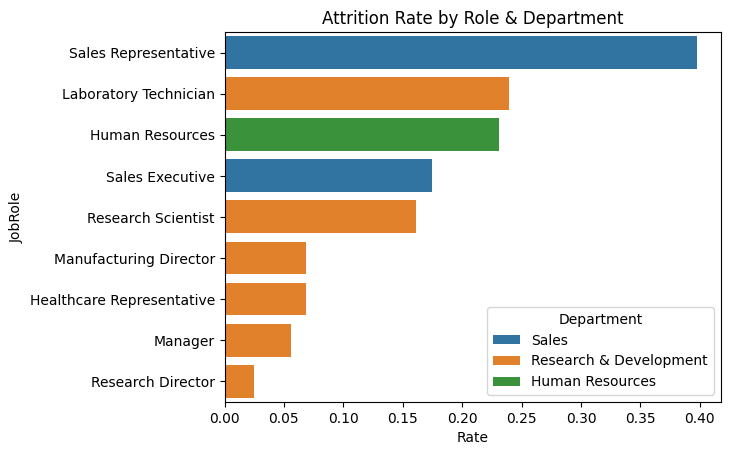

In [33]:

plot_df = df.assign(Rate = df['Attrition'] == 'Yes').groupby(['JobRole', 'Department'])['Rate'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=plot_df, x='Rate', y='JobRole', hue='Department', dodge=False)
plt.title('Attrition Rate by Role & Department')
plt.show()


High-Risk Roles and Departments: The strongest behavioral signal for attrition is the combination of specific job roles and their departments. Sales Representatives show the highest attrition rate (nearly 40%), significantly outpacing other roles. Within Research & Development, while the department is large, Laboratory Technicians are at much higher risk than Managers or Research Directors.

Structural Stability (Job Level): There is a clear negative correlation between JobLevel and attrition (-0.17), meaning as employees move to higher seniority levels, they become less likely to leave. This suggests that "early-career churn" is a significant factor, where employees in entry-level positions (Job Level 1–2) are more mobile and prone to exit than established senior staff.

Lifestyle and Work Friction: External stressors like Business Travel and Distance From Home act as secondary attrition drivers. While most employees travel rarely, those who travel frequently show a higher ratio of attrition compared to their peers. Additionally, there is a positive correlation between commuting distance and the likelihood of leaving, indicating that "lifestyle friction" increases the probability of an employee seeking a new role.

In [34]:
#Now we'll the factors for Compensation and financials:
# Checking columns MonthlyIncome,MonthlyRate,DailyRate,HourlyRate,PercentSalaryHike,StockOptionLevel

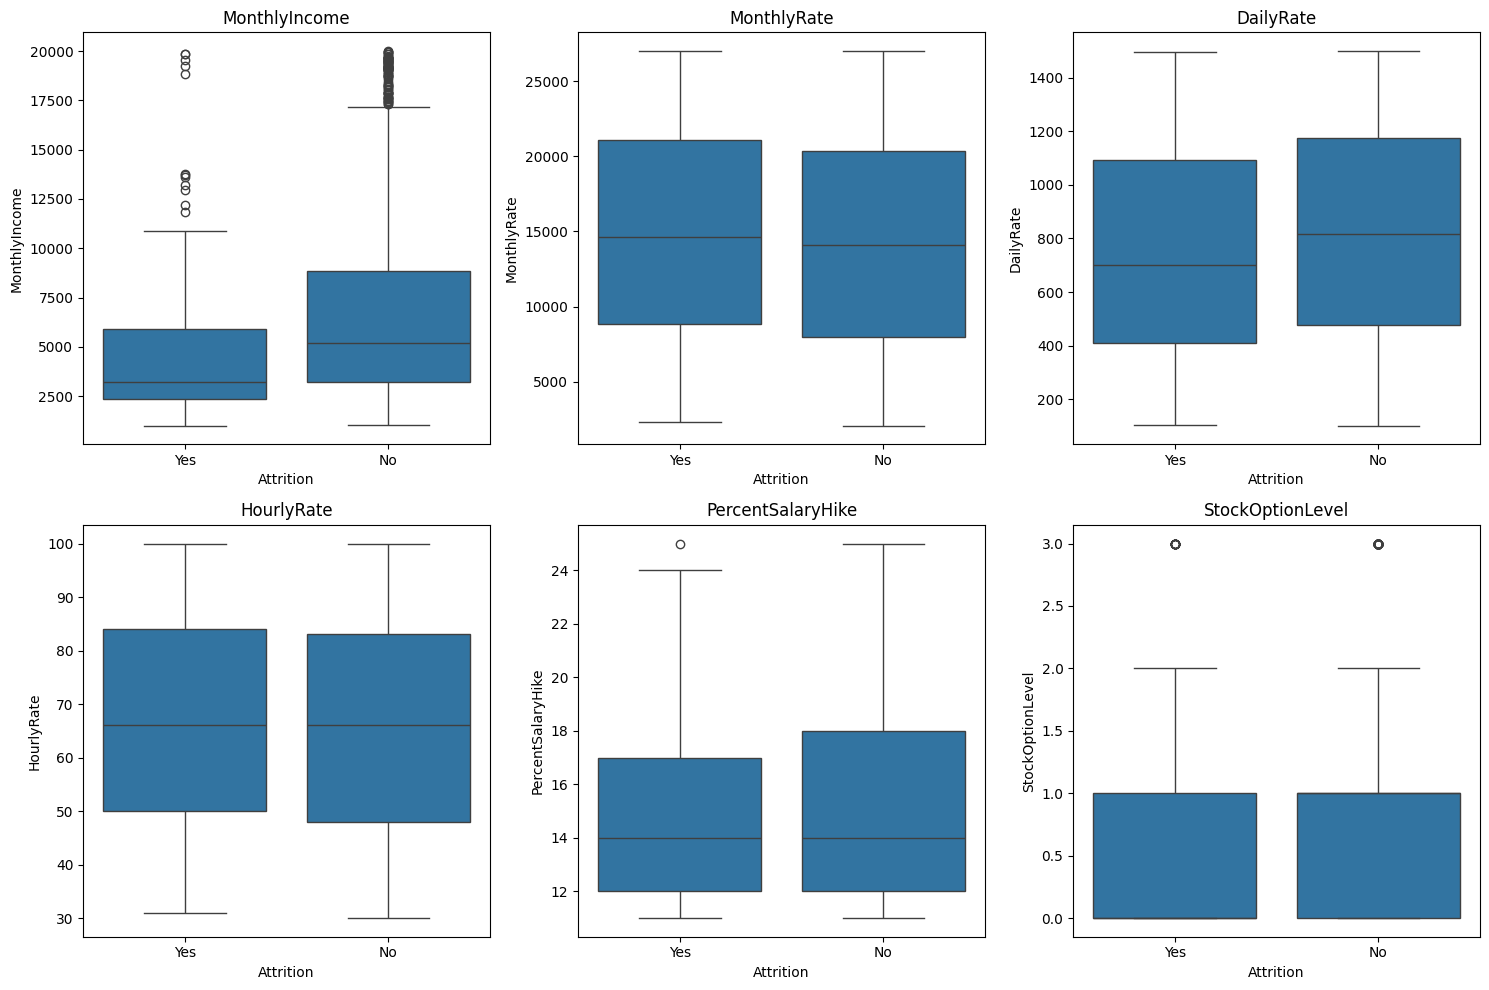

In [35]:

finance_cols = ['MonthlyIncome', 'MonthlyRate', 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel']
plt.figure(figsize=(15, 10))
for i, col in enumerate(finance_cols):
    plt.subplot(2, 3, i + 1) 
    sns.boxplot(data=df, x='Attrition', y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

Conclusion

Monthly Income is a significant factor: Employees who left ("Yes") generally had a notably lower median monthly income compared to those who stayed ("No"), suggesting lower pay correlates with higher attrition.

Hourly and Monthly Rates are negligible: Both HourlyRate and MonthlyRate show nearly identical distributions and median values for both groups, indicating these specific pay structures do not drive the decision to leave.

Daily Rate shows slight variation: While the ranges are similar, employees who stayed ("No") have a slightly higher median DailyRate than those who left, hinting at a minor trend where higher daily earners are more likely to remain.

The box plot for Percent Salary Hike shows nearly identical medians (14%) and interquartile ranges (12% to 18%) for both groups, the presence of a high-end outlier in the "Yes" category and a slightly fuller top whisker in the "No" category

Stock Option Levels are uniform: The StockOptionLevel distributions for "Yes" and "No" are identical, with the same median and interquartile range, showing that stock option levels (up to level 3) do not differentiate those who leave from those who stay.

High-income outliers are less likely to leave: The MonthlyIncome chart shows that while there are high-earning outliers in both groups, the density of extreme high-earners (near 20,000) is much higher in the group that stayed.


Let's check the correlation among these variables

<Axes: >

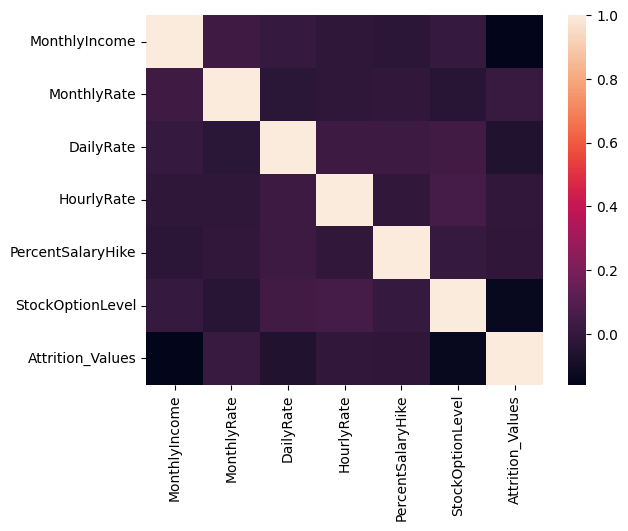

In [36]:
df['Attrition_Values']=df['Attrition'].apply(lambda x:1 if x=='Yes' else 0)
variables = [
    'MonthlyIncome', 'MonthlyRate', 'DailyRate', 
    'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel', 
    'Attrition_Values'
]
corr_df=df[variables].corr()
sns.heatmap(corr_df)


MonthlyRate, DailyRate, and HourlyRate,PercentSalaryHike: These four variables show nearly identical distributions for both those who stayed and those who left. The heatmap also confirms they have a near-zero correlation with Attrition_Values. Keeping all three may just add "noise" to a machine learning model.



In [37]:
df['StockOptionLevel'].corr(df['MonthlyIncome'])

0.005407676696812231

In [38]:
df.drop(columns=['MonthlyRate', 'DailyRate', 
    'HourlyRate', 'PercentSalaryHike'] ,inplace=True)
    

In [39]:
df.shape

(1470, 29)

In [40]:
## Now we will be checking Satisfaction and sentimental factors
#EnvironmentSatisfaction,JobInvolvement,JobSatisfaction ,RelationshipSatisfaction,WorkLifeBalance

<Axes: >

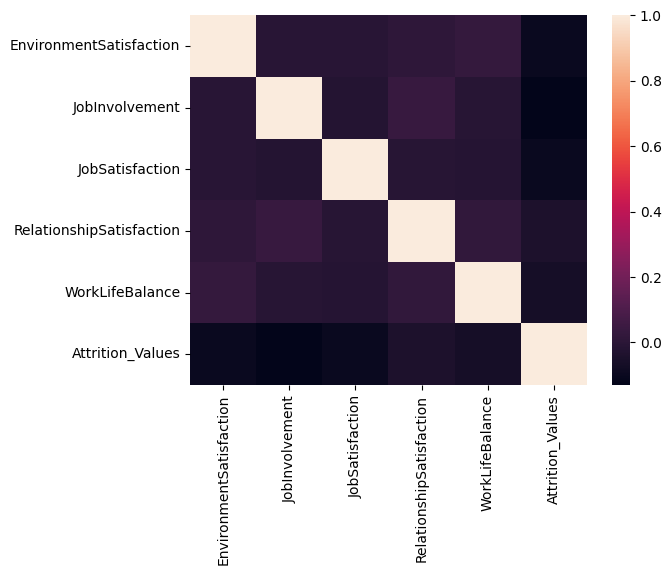

In [41]:
df['Attrition_Values']=df['Attrition'].apply(lambda x:1 if x=='Yes' else 0)
variables = [
    'EnvironmentSatisfaction','JobInvolvement','JobSatisfaction' ,'RelationshipSatisfaction','WorkLifeBalance','Attrition_Values'
]
corr_df=df[variables].corr()
sns.heatmap(corr_df)

In [42]:
df['Attrition_values'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
variables = [
    'EnvironmentSatisfaction','JobInvolvement','JobSatisfaction' ,'RelationshipSatisfaction','WorkLifeBalance'
]
for i in variables:
    correlation=df[i].corr(df['Attrition_values'])
    print(correlation)



-0.10336897833793582
-0.13001595678605318
-0.10348112606902085
-0.04587227888112602
-0.06393904721740896


 All the satisfactory variables have a negative correlation with the target variables

In [43]:
# Now we'll look into our final category of dataset which is "Career History and Performance"
#Education,EducationField,NumCompaniesWorked,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager

<Axes: xlabel='Education', ylabel='Attrition_values'>

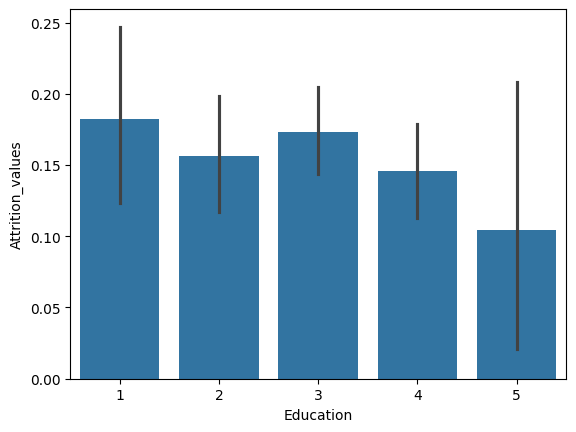

In [44]:
sns.barplot(x='Education',y='Attrition_values',data=df)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Life Sciences'),
  Text(1, 0, 'Other'),
  Text(2, 0, 'Medical'),
  Text(3, 0, 'Marketing'),
  Text(4, 0, 'Technical Degree'),
  Text(5, 0, 'Human Resources')])

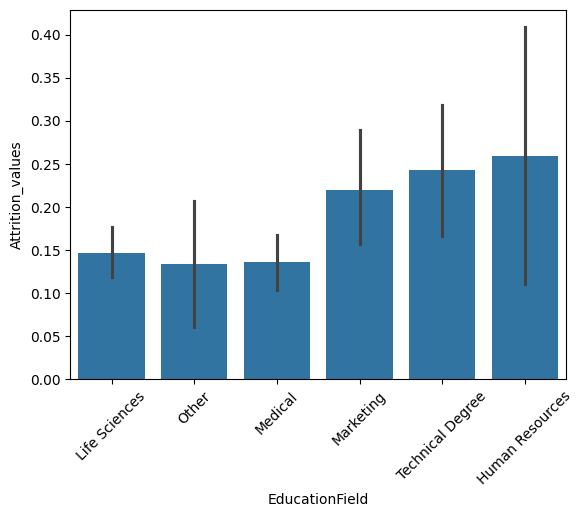

In [45]:
sns.barplot(x='EducationField',y='Attrition_values',data=df)
plt.xticks(rotation=45)

In [46]:
#Employees with highest education level choose to stay in the company more.
#The company might need to investigate if their HR and Technical roles are underpaid or if the work culture in that specific department is toxic

In [47]:
df.drop(columns=[
    'Education','EducationField'
], inplace=True)

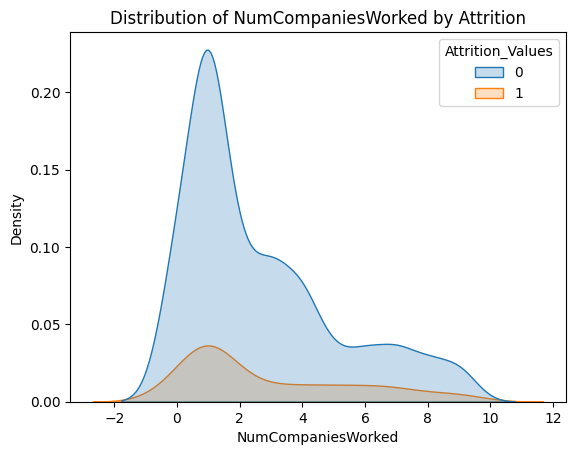

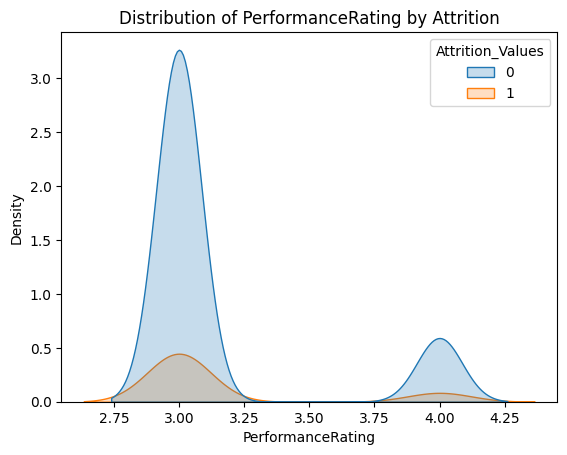

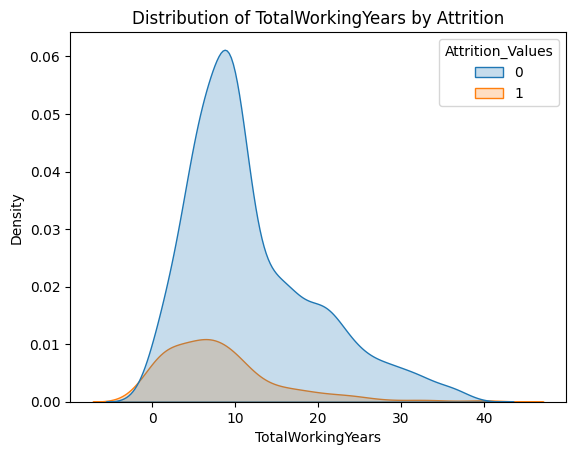

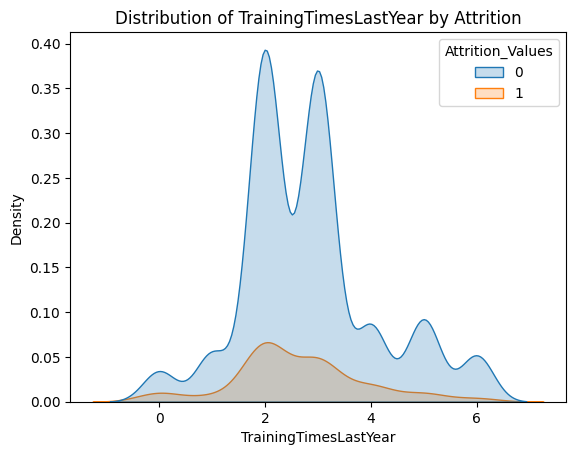

In [48]:
 
career_metrics = ['NumCompaniesWorked', 'PerformanceRating', 'TotalWorkingYears', 'TrainingTimesLastYear']

for i in career_metrics:
    sns.kdeplot(data=df, x=i, hue='Attrition_Values', fill=True) 
    plt.title(f'Distribution of {i} by Attrition')
    plt.show()


The TotalWorkingYears  plot reveals that attrition is most common among employees in the early-to-mid stages of their careers. Specifically, there is a significant spike in departures for those with approximately 5 to 10 years of total experience

When looking at the NumCompaniesWorked distribution, there is a high concentration of attrition for employees who have worked at only one or two previous companies

The PerformanceRating plot shows a bimodal distribution with clear peaks at ratings of 3.0 and 4.0. What stands out here is the proportionality: the ratio of employees leaving versus those staying remains relatively consistent across both performance levels

The TrainingTimesLastYear plot suggests that Most employees received 2 to 3 training sessions, which is also where the bulk of attrition occurs.

<Axes: >

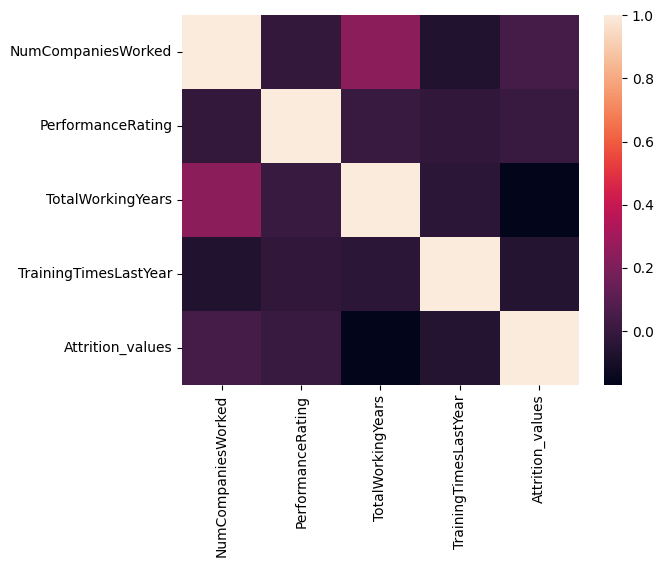

In [49]:
variables = [
    'NumCompaniesWorked', 'PerformanceRating', 'TotalWorkingYears', 'TrainingTimesLastYear','Attrition_values'
]
corr_df=df[variables].corr()
sns.heatmap(corr_df)

In [50]:

variables = [
    'NumCompaniesWorked', 'PerformanceRating', 'TotalWorkingYears', 'TrainingTimesLastYear','Attrition_values'
]
for i in variables:
    correlation=df[i].corr(df['Attrition_values'])
    print(correlation)

0.043493739057813625
0.002888751711080899
-0.17106324613622614
-0.05947779855642029
1.0


In [51]:
#Performance Rating has no correlation with Attrition,so iit needs to be removed.

In [52]:
df.drop(columns=[
    'PerformanceRating'
], inplace=True)

In [53]:
#Total working hours and Num of companies worked have + correlation

<Axes: xlabel='TotalWorkingYears', ylabel='NumCompaniesWorked'>

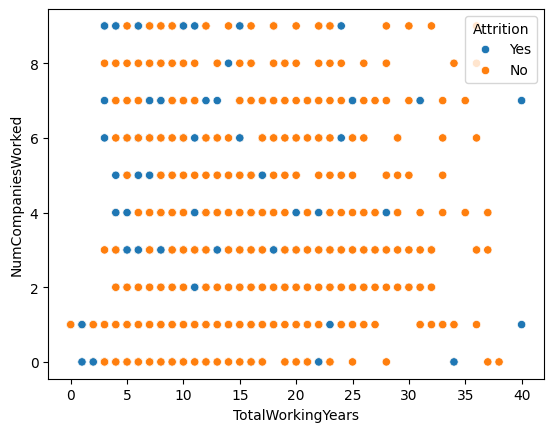

In [54]:
sns.scatterplot(data=df, x='TotalWorkingYears', y='NumCompaniesWorked', hue='Attrition')

The "Job-Hopper" Risk: Notice the cluster of blue dots in the upper-left quadrant (specifically between 0–10 years of experience and 5–9 companies worked). This suggests that employees who have worked at many companies in a short span of time are more likely to leave.

The Stability Zone: The dense concentration of orange dots along the bottom (0–2 companies worked) across almost all experience levels suggests that employees with fewer previous employers tend to be more loyal/stable.

Early Career Sensitivity: There is a significant amount of blue (attrition) among employees with less than 10 total working years, regardless of how many companies they’ve been with. This is common as early-career professionals often move around to find the right "fit" or higher pay.

Late Career Outliers: Beyond 30 years of experience, attrition is very rare (mostly orange), with only a few blue dots. These blue dots at the 35-40 year mark likely represent retirements rather than standard resignations.

<Axes: >

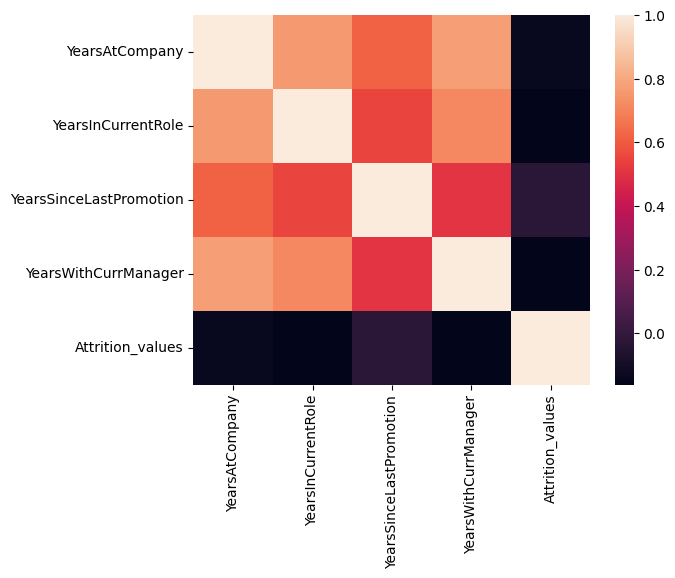

In [55]:
variables = [
    'YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager','Attrition_values'
]
corr_df=df[variables].corr()
sns.heatmap(corr_df)

In [56]:
variables = [
    'YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager','Attrition_values'
]
for i in variables:
    correlation=df[i].corr(df['Attrition_values'])
    print(correlation)

-0.13439221398997675
-0.16054500426770077
-0.033018775142584285
-0.15619931590162864
1.0


In [57]:
#Feature Engineering

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   EnvironmentSatisfaction   1470 non-null   int64 
 6   Gender                    1470 non-null   object
 7   JobInvolvement            1470 non-null   int64 
 8   JobLevel                  1470 non-null   int64 
 9   JobRole                   1470 non-null   object
 10  JobSatisfaction           1470 non-null   int64 
 11  MaritalStatus             1470 non-null   object
 12  MonthlyIncome             1470 non-null   int64 
 13  NumCompaniesWorked        1470 non-null   int64 
 14  OverTime                

In [59]:
#Label Encoding for Binary Variables

df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df['OverTime'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

In [60]:
#One-Hot Encoding for Nominal Variables
# Create dummy variables for the categorical columns

df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus'], drop_first=True)

In [61]:
df.head()

,Age,Attrition,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,2,0,3,2,4,5993,8,...,False,False,False,False,False,False,True,False,False,True
1,49,0,8,3,1,2,2,2,5130,1,...,False,False,False,False,False,True,False,False,True,False
2,37,1,2,4,1,2,1,3,2090,6,...,False,True,False,False,False,False,False,False,False,True
3,33,0,3,4,0,3,1,3,2909,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,2,1,1,3,1,2,3468,9,...,False,True,False,False,False,False,False,False,True,False


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   EnvironmentSatisfaction            1470 non-null   int64
 4   Gender                             1470 non-null   int64
 5   JobInvolvement                     1470 non-null   int64
 6   JobLevel                           1470 non-null   int64
 7   JobSatisfaction                    1470 non-null   int64
 8   MonthlyIncome                      1470 non-null   int64
 9   NumCompaniesWorked                 1470 non-null   int64
 10  OverTime                           1470 non-null   int64
 11  RelationshipSatisfaction           1470 non-null   int64
 12  StockOptionLevel    

In [63]:
df.drop(columns=['Attrition_Values','Attrition_values','Attrition_Rate'],inplace=True) 

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   EnvironmentSatisfaction            1470 non-null   int64
 4   Gender                             1470 non-null   int64
 5   JobInvolvement                     1470 non-null   int64
 6   JobLevel                           1470 non-null   int64
 7   JobSatisfaction                    1470 non-null   int64
 8   MonthlyIncome                      1470 non-null   int64
 9   NumCompaniesWorked                 1470 non-null   int64
 10  OverTime                           1470 non-null   int64
 11  RelationshipSatisfaction           1470 non-null   int64
 12  StockOptionLevel    

In [65]:
#Model Building

In [66]:
X=df.drop(columns=['Attrition'])
y=df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

Training shape: (1176, 33)
Testing shape: (294, 33)


In [67]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)


model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=12,
    random_state=42,
    class_weight='balanced' 
)
model.fit(X_train_res, y_train_res)

y_probs = model.predict_proba(X_test_scaled)[:, 1]

target_threshold = 0.26 
y_pred = (y_probs >= target_threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.77      0.85       247
           1       0.38      0.74      0.51        47

    accuracy                           0.77       294
   macro avg       0.66      0.76      0.68       294
weighted avg       0.85      0.77      0.79       294



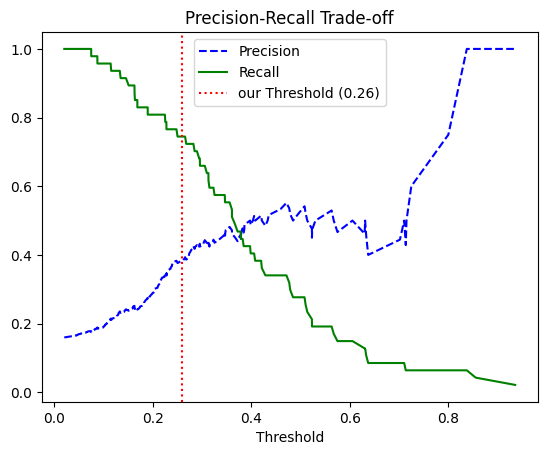

In [68]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.axvline(x=0.26, color='red', linestyle=':', label='our Threshold (0.26)')
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall Trade-off")
plt.show()

1. The Recall VictoryBy setting the threshold at 0.26 (the red dotted line), you are catching approximately 70-74% of employees who are likely to leave (Recall). If you had stayed at the default 0.5 threshold, your Recall would have plummeted to roughly 35-40%, meaning you would have missed more than half of the people planning to quit.
2. The Precision "Tax"At 0.26, your Precision is sitting around 0.38 (38%).What this means in plain English: For every 100 people your model flags as "At Risk," about 38 will actually leave, and 62
3.  are "false alarms" (people the model thought might leave but aren't actually going anywhere).Is this okay? In HR analytics, yes. It is usually much cheaper to offer a "stay interview" or a small incentive to 62 people who weren't leaving than it is to lose even one of those 38 high-value employees because you didn't see it coming.
4. Comparing to the "Break-Even" PointThe "Optimal" point where Precision and Recall meet is around a threshold of 0.44.At 0.44, both metrics are roughly 45%.By choosing 0.26, you are intentionally making a "Value Judgment": You are saying that Recall is more important than Precision. This is the correct mindset for churn and attrition modeling.

In [69]:
#Model B

We will Predict the ELTV value for the churners and thereby calculating necessary steps to be taken.

ELTV (Employee Lifetime Value) is a metric used to quantify the net value an employee brings to an organization over the entire duration of their tenure
    
ELTV = MonthlyIncome * TotalWorkingYears

In [70]:
df2=df

In [71]:
# 1. Create the ELTV Target Variable
df['ELTV'] = df['MonthlyIncome'] * df['TotalWorkingYears']


In [72]:
df.drop(columns=['MonthlyIncome','TotalWorkingYears'],inplace=True)

In [73]:

cols_to_drop = ['Attrition', 'ELTV']
X_eltv = df.drop(columns=['ELTV'])
y_eltv = df['ELTV']


from sklearn.model_selection import train_test_split
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eltv, y_eltv, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor
eltv_model = RandomForestRegressor(n_estimators=100, random_state=42)
eltv_model.fit(X_train_e, y_train_e)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [74]:
# Evaluate the model on the test set
r2_score = eltv_model.score(X_test_e, y_test_e)

print(f"Model R^2 Score: {r2_score:.4f}")


Model R^2 Score: 0.9379


In [75]:
print(eltv_model.score(X_train_e, y_train_e))

print(eltv_model.score(X_test_e, y_test_e))

0.991278043248454
0.9378699137778661


In [79]:
def predict_employee_strategy(user_input, clf_model, reg_model, scaler, 
                              clf_train_cols, eltv_train_cols, eltv_q75, eltv_q90):
    """
    Predicts attrition risk and ELTV, then provides a tailored retention strategy.
    """
    # 1. Convert dictionary input to DataFrame
    input_df = pd.DataFrame([user_input])
    
    # 2. One-Hot Encoding
    input_encoded = pd.get_dummies(input_df)
    
    # 3. Handle Classification (Risk) Features
    # reindex ensures the input has exactly the same columns as the training set X
    input_final_clf = input_encoded.reindex(columns=clf_train_cols, fill_value=0)
    input_scaled_clf = scaler.transform(input_final_clf)
    risk_prob = clf_model.predict_proba(input_scaled_clf)[0][1]
    
    # 4. Handle Regression (ELTV) Features
    # reindex aligns with the specific features used for the ELTV model
    input_final_eltv = input_encoded.reindex(columns=eltv_train_cols, fill_value=0)
    pred_eltv = reg_model.predict(input_final_eltv)[0]
    
    # 5. Define Strategy Logic
    risk_threshold = 0.26  # Your optimal threshold from the notebook
    high_risk_severe = 0.40 # Defined threshold for severe flight risk
    
    # Tier 1: The Top 10% (Highest Value Assets)
    if pred_eltv >= eltv_q90:
        if risk_prob >= high_risk_severe:
            advice = "CRITICAL: Top 10% Talent at High Risk. Executive intervention required."
        elif risk_prob >= risk_threshold:
            advice = "PRIORITY: High Value flight risk. Discuss long-term equity/vesting."
        else:
            advice = "CHAMPION: Key Asset. Stable, but ensure continued high-level engagement."

    # Tier 2: The Top 25% (High Value Assets)
    elif pred_eltv >= eltv_q75:
        if risk_prob >= high_risk_severe:
            advice = "CRITICAL: Senior Level Flight Risk. Review promotion/salary status."
        elif risk_prob >= risk_threshold:
            advice = "MONITOR: High Value Risk. Standard retention bonus advised."
        else:
            advice = "PROTECT: High Value Stable. Maintain standard growth path."

    # Tier 3: Standard Employees (Below 75th percentile)
    else:
        if risk_prob >= risk_threshold:
            advice = "MONITOR: Standard Flight Risk. Evaluate cost of hire vs. retention."
        else:
            advice = "STABLE: Low risk, standard engagement sufficient."
        
    return {
        "Risk Probability": f"{risk_prob:.2%}",
        "Predicted ELTV": f"${pred_eltv:,.2f}",
        "Strategy Advice": advice
    }

In [80]:
eltv_q75 = df['ELTV'].quantile(0.75)
eltv_q90 = df['ELTV'].quantile(0.90)


final_critical_input = {
    'Age': 25,
    'BusinessTravel': 'Travel_Frequently',
    'Department': 'Research & Development',
    'MonthlyIncome': 1500,        
    'TotalWorkingYears': 10,      
    'DistanceFromHome': 29,        
    'Education': 5,                
    'EducationField': 'Life Sciences',
    'EnvironmentSatisfaction': 1,  
    'Gender': 'Female',
    'JobInvolvement': 1,          
    'JobLevel': 5,                 #
    'JobRole': 'Manager',          
    'JobSatisfaction': 1,          
    'MaritalStatus': 'Single',     
    'NumCompaniesWorked': 1,       
    'OverTime': 'Yes',             
    'PercentSalaryHike': 0,        
    'PerformanceRating': 4,        
    'RelationshipSatisfaction': 1,
    'StockOptionLevel': 0,         
    'TrainingTimesLastYear': 0,    
    'WorkLifeBalance': 1,         
    'YearsAtCompany': 5,          
    'YearsInCurrentRole': 1,      
    'YearsSinceLastPromotion': 3, 
    'YearsWithCurrManager': 6
}

result = predict_employee_strategy(
    user_input=final_critical_input, 
    clf_model=model,                       
    reg_model=eltv_model,            
    scaler=scaler,                         
    clf_train_cols=X.columns,              
    eltv_train_cols=X_eltv.columns, 
    eltv_q75=eltv_q75,
    eltv_q90=eltv_q90
)

print("-" * 30)
for key, value in result.items():
    print(f"{key}: {value}")

------------------------------
Risk Probability: 49.87%
Predicted ELTV: $259,193.05
Strategy Advice: CRITICAL: Senior Level Flight Risk. Review promotion/salary status.


In [ ]:
#Exporting The Model

In [86]:
import pickle

pickle.dump(model, open('attrition_model.pkl', 'wb'))         
pickle.dump(eltv_model, open('eltv_model.pkl', 'wb'))    
pickle.dump(scaler, open('scaler.pkl', 'wb'))

pickle.dump(X.columns.tolist(), open('clf_features.pkl', 'wb'))
pickle.dump(X_eltv.columns.tolist(), open('eltv_features.pkl', 'wb'))

pickle.dump(eltv_q75, open('eltv_q75.pkl', 'wb'))
pickle.dump(eltv_q90, open('eltv_q90.pkl', 'wb'))



print("All files dumped successfully!")

All files dumped successfully!


In [90]:
import pandas as pd
import pickle

# 1. Reload the RAW data (Replace 'WA_Fn-UseC_-HR-Employee-Attrition.csv' with your filename)
df_raw = df_copy 

# 2. List of columns we need for the UI
categorical_columns = [
    'BusinessTravel', 'Department', 'EducationField', 
    'Gender', 'JobRole', 'MaritalStatus', 'OverTime'
]

categorical_options = {}

# 3. Extract unique values from the RAW data
for col in categorical_columns:
    if col in df_raw.columns:
        categorical_options[col] = df_raw[col].unique().tolist()
        print(f"✅ Success: Extracted {col}")
    else:
        print(f"❌ Error: {col} not found even in raw file.")

# 4. Save to pickle
with open('cat_options.pkl', 'wb') as f:
    pickle.dump(categorical_options, f)

print("\n--- DONE: 'cat_options.pkl' now contains all categories! ---")

✅ Success: Extracted BusinessTravel
✅ Success: Extracted Department
✅ Success: Extracted EducationField
✅ Success: Extracted Gender
✅ Success: Extracted JobRole
✅ Success: Extracted MaritalStatus
✅ Success: Extracted OverTime

--- DONE: 'cat_options.pkl' now contains all categories! ---
